In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

In [4]:
df = pd.read_csv('../df_procesados/df_planta_2.csv')
df['date_time'] = pd.to_datetime(df['date_time'])

### Modelo Flujo Camara de contacto 2

In [7]:
col = df.columns[-1]
col

'Flujo Cámara de contacto 2'

In [28]:
serie = df.set_index('date_time')[col]

serie = serie.dropna()

serie = serie[:10000]

serie_diff = serie.diff().dropna()

modelo = ARIMA(serie_diff, order=(5, 0, 1))
resultado = modelo.fit()

C:\Users\vicen\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\vicen\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\vicen\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


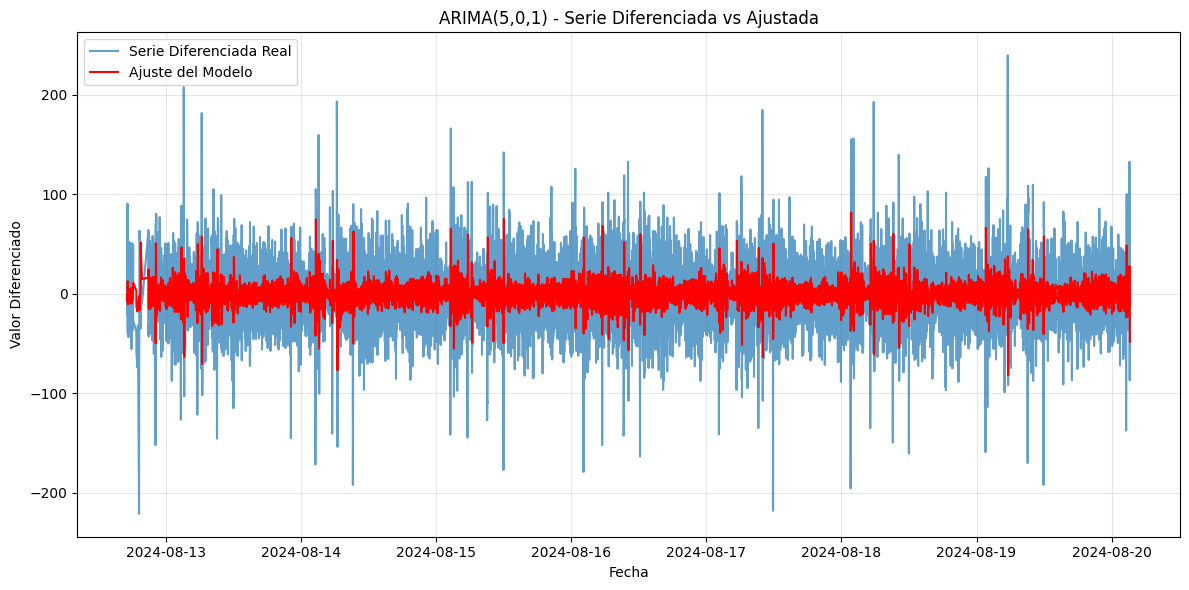

In [29]:
plt.figure(figsize=(12, 6))
plt.plot(serie_diff.index, serie_diff.values, label='Serie Diferenciada Real', alpha=0.7)
plt.plot(serie_diff.index, resultado.fittedvalues, label='Ajuste del Modelo', color='red', linewidth=1.5)
plt.title('ARIMA(5,0,1) - Serie Diferenciada vs Ajustada')
plt.xlabel('Fecha')
plt.ylabel('Valor Diferenciado')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

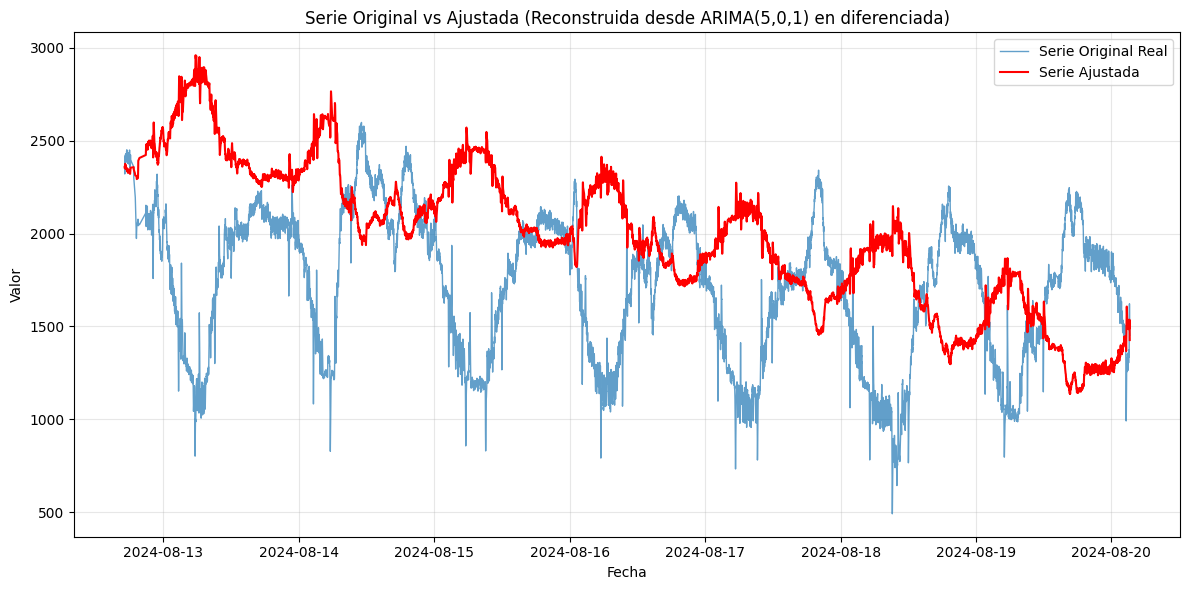

In [34]:
serie_ajustada_original = serie.iloc[0] + resultado.fittedvalues.cumsum()

plt.figure(figsize=(12, 6))
plt.plot(serie.index, serie.values, label='Serie Original Real', alpha=0.7, linewidth=1)
plt.plot(serie_ajustada_original.index, serie_ajustada_original.values, 
         label='Serie Ajustada', color='red', linewidth=1.5)
plt.title('Serie Original vs Ajustada (Reconstruida desde ARIMA(5,0,1) en diferenciada)')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Modelo de flujo afluente PTAR

In [37]:
col = df.columns[6]
col

'Flujo Afluente PTAR'

In [38]:
serie = df.set_index('date_time')[col]

serie = serie.dropna()

serie = serie[:10000]

lambda_box = 0.5789277
serie_box = ((serie ** lambda_box) - 1) / lambda_box

modelo = ARIMA(serie_box, order=(5, 1, 0))
resultado = modelo.fit()

C:\Users\vicen\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\vicen\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\vicen\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


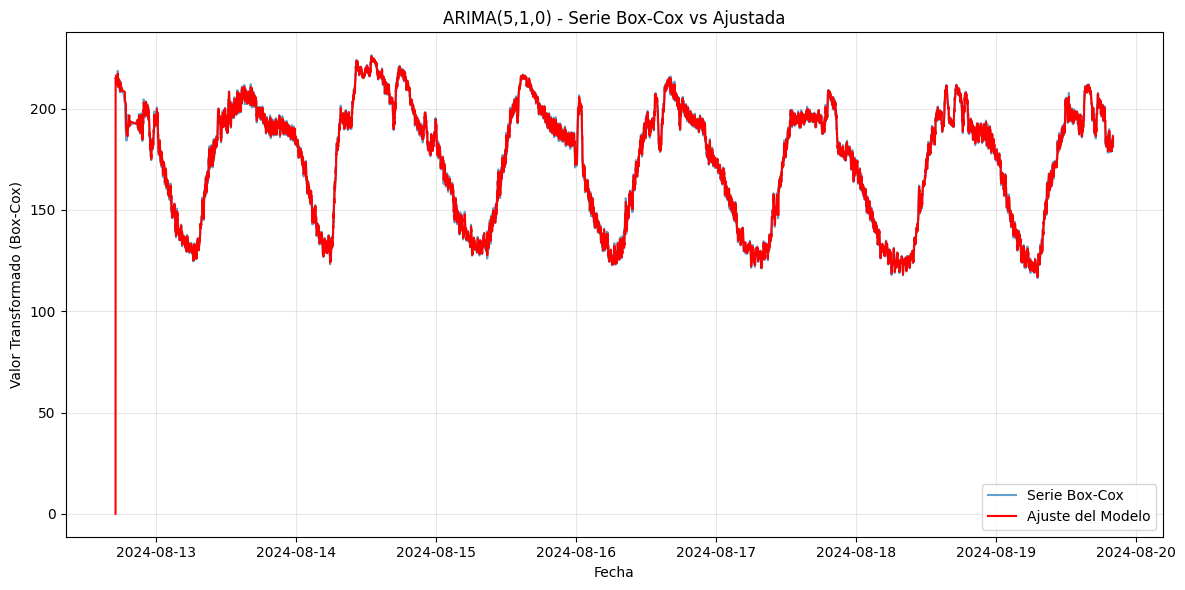

In [40]:
plt.figure(figsize=(12, 6))
plt.plot(serie_box.index, serie_box.values, label='Serie Box-Cox', alpha=0.7)
plt.plot(serie_box.index, resultado.fittedvalues, label='Ajuste del Modelo', color='red', linewidth=1.5)
plt.title('ARIMA(5,1,0) - Serie Box-Cox vs Ajustada')
plt.xlabel('Fecha')
plt.ylabel('Valor Transformado (Box-Cox)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

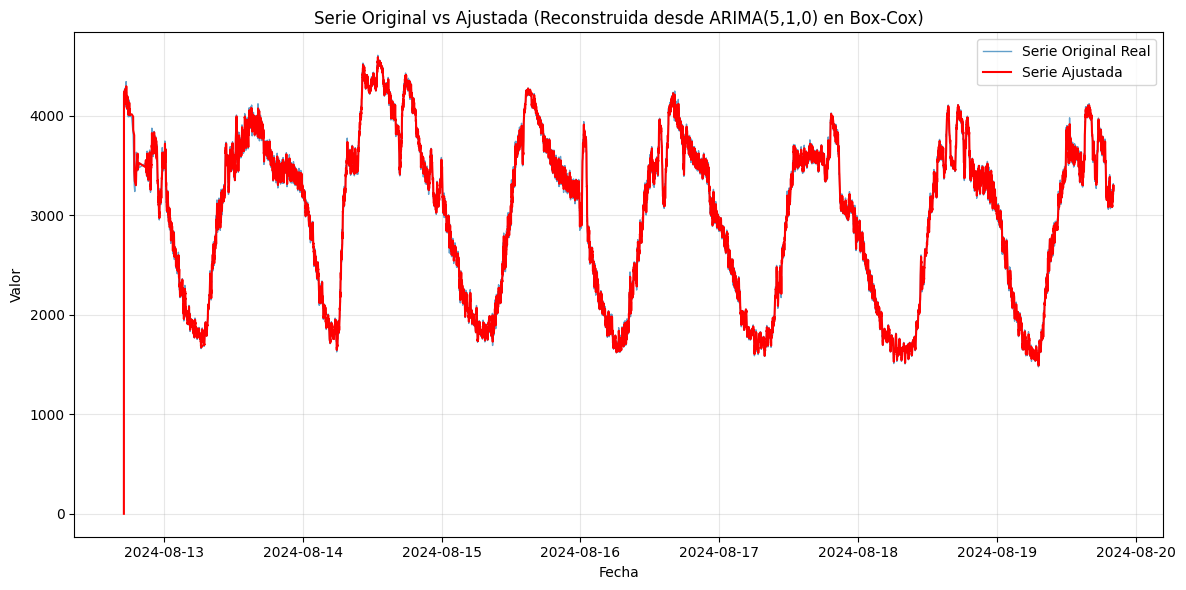

In [41]:
serie_ajustada_inversa = (lambda_box * resultado.fittedvalues + 1) ** (1 / lambda_box)

plt.figure(figsize=(12, 6))
plt.plot(serie.index, serie.values, label='Serie Original Real', alpha=0.7, linewidth=1)
plt.plot(serie_ajustada_inversa.index, serie_ajustada_inversa.values, 
         label='Serie Ajustada', color='red', linewidth=1.5)
plt.title('Serie Original vs Ajustada (Reconstruida desde ARIMA(5,1,0) en Box-Cox)')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()